1) To find the theoretical tunning time, I'll analyse the formula:
$$Cosine Similarity = cos(\theta) = \frac{A \cdot B} {\sqrt {A \cdot A \times B \cdot B}}$$

It is made up of the dot product of 2 vectors ($A$ and $B$) as the numerator, and the multiplication of the dot product of $A$ with itself and $B$ with itself, all square rooted as the denominator. 

$A \cdot B$ represents the operation $$\mathbf{A} \cdot \mathbf{B} = \sum_{i=1}^{n} A_i B_i$$ So a simple multiplication operation between $A_i B_i$ with time complexity $0(1)$ carried out for every $n$ (equal to the length of A) element, and the summation of of all of those results- summation being just addition ($O(1)$) carried out $n-1$ times. Carrying out $n$ multiplications here is of $O(n)$ time complexity, as is the summation calculation as $n-1 \approx n$, so these dominate this expression, so the overall time complexity for the numerator in cosine similarity is $2O(n) \approx O(n)$ 

By the same logic the $A \cdot A$ component and $B \cdot B$ component are also $O(n)$ time complexity. Given that the mutiplication of $A \cdot A$ with  $B \cdot B$ is a simple multiplication ($O(1)$), finding the root of this is also $O(1)$, and finally- dividing the numerator by the denominator is also $O(1)$, the $O(n)$ terms dominate the time complexity and so the overall theoretical time complexity for calculating cosine similarity on a pair of vectors is therefore $O(n)$.


- My first step is to use the my_data_array and slice it into columns- can either transpose and take rows or take columns as lists.
- Next I need a means to compute cosine similarity between 2 docs
- Next will be to import a means of timing the function
- I will plot the time taken to calculate the cosine similarity for lists representing slices of varying lengths of the document-vectors and I would expect that the time to compute would vary linearly with the length of the slices I use.

In [ ]:
import pandas as pd
import time
import math
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import random

data1=pd.read_csv('data2024.csv', index_col=0)

#print(data1)

my_data_array=data1.values

documents = data1.to_numpy()

print(documents[0])
#print(my_data_array)

In [ ]:
# Create a dictionary to store each document
#dict_of_docs = {f'doc_{i}': data1.iloc[:, i-1] for i in range(1, 16)}
#print(dict_of_docs)
# Access an individual document, e.g., doc_1
#doc_1 = dict_of_docs['doc_1']
#doc_2 = dict_of_docs['doc_2']
#print(doc_1)

#doc_by_ref1 = data1.iloc[:,0]
#doc_by_ref2 = data1.iloc[:,1]
#print(doc_by_ref1)

length_of_data = len(doc_1)


doc_1 = my_data_array[:,0] #first column as a list
doc_2 = my_data_array[:,1] #second
doc_3 = my_data_array[:,2]

list_of_docs = [my_data_array[:,i] for i in range(15)]

print(list_of_docs)
def dotn(v1,v2):
    total=0
    for i in range(0,len(v1)):
        total+=v1[i]*v2[i]
        
    return total

def cosine_n(v1,v2): #cosine naive
    
    return dotn(v1,v2)/math.sqrt(dotn(v1,v1)*dotn(v2,v2))

cos_of_pair12 = cosine_n(doc_1,doc_2)
print(cos_of_pair12) #gives 0.94097


In [13]:
def timeit(somefunc,*args,repeats=200,**kwargs):   # timing function
    times=[]
  
    while repeats>0:
        starttime=time.time()
        ans=somefunc(*args,**kwargs)
        endtime=time.time()
        timetaken=endtime-starttime
        times.append(timetaken)
        repeats-=1
    
    mean=np.mean(times)
    stdev=np.std(times)
 
    return (mean)

x_cos =[]
y_cos =[]

In [15]:
def make_data(start, end, jump, some_func, v1, v2, repeats=20, *args, **kwargs):
    """
    Generate datasets by applying the `timeit` function on `some_func` over a range of inputs.

    Args:
        start (int): Starting value for the range of `n`.
        end (int): Ending value for the range of `n`.
        jump (int): Step size for the range.
        some_func (function): Function to be timed, which takes two positional arguments.
        v1 (list or np.ndarray): The first argument to `some_func` (list or vector to be sliced).
        v2 (list or np.ndarray): The second argument to `some_func` (list or vector to be sliced).
        repeats (int): Number of times to repeat the timing for each value of `n`.
        *args: Additional positional arguments for `some_func`.
        **kwargs: Additional keyword arguments for `some_func`.

    Returns:
        tuple: (x_data, y_data) where x_data is the range of `n` and y_data is the mean times.
    """
    x_data = []
    y_data = []

    for n in range(start, end, jump):
        # Dynamically slice v1 and v2 based on n
        sliced_v1 = v1[:n]
        sliced_v2 = v2[:n]
        
        # Time the function with the dynamically sliced arguments
        mean_time = timeit(some_func, sliced_v1, sliced_v2, repeats=repeats, *args, **kwargs)
        
        # Store the results
        x_data.append(n)
        y_data.append(mean_time)

    return x_data, y_data


In [153]:
(x_cos, y_cos) = make_data(50, 21000, 200, cosine_n, doc_1,doc_2,repeats= 100) # start must be at least 38 as doc 2 is zeros until then

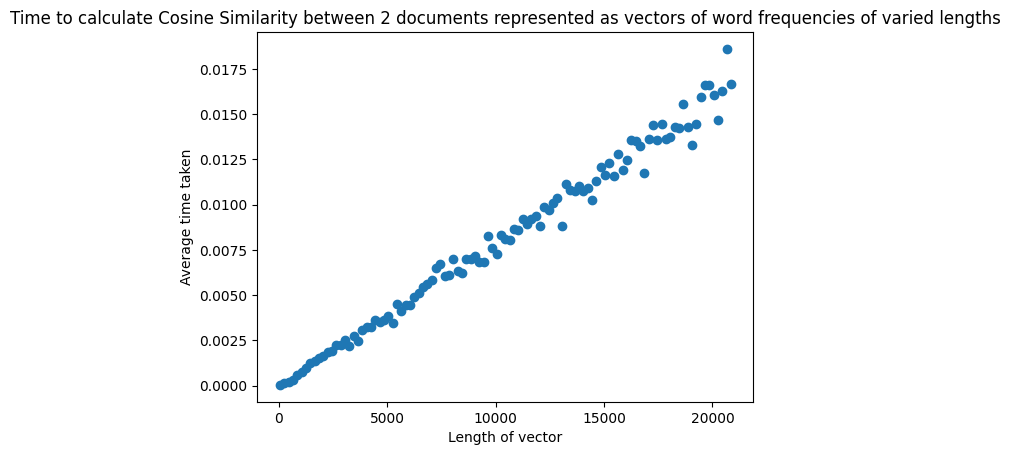

In [155]:
plt.scatter(x_cos,y_cos)
#plt.ylim(0,0.005)
plt.xlabel("Length of vector")
plt.ylabel("Average time taken")
plt.title("Time to calculate Cosine Similarity between 2 documents represented as vectors of word frequencies of varied lengths")
plt.show()

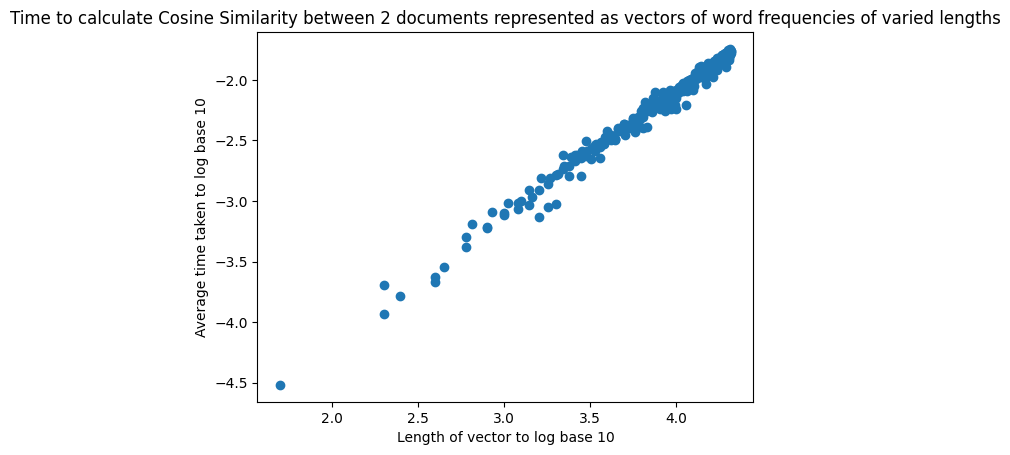

Slope is 1.0204711719735091 and intercept is -6.181635720765554


In [53]:
log_xcos=[np.log10(x) for x in x_cos]
log_ycos=[np.log10(y) for y in y_cos]

plt.scatter(log_xcos,log_ycos)
#plt.ylim(0,0.005)
plt.xlabel("Length of vector to log base 10")
plt.ylabel("Average time taken to log base 10")
plt.title("Time to calculate Cosine Similarity between 2 documents represented as vectors of word frequencies of varied lengths")
plt.show()

res = stats.linregress(log_xcos, log_ycos)
print("Slope is {} and intercept is {}".format(res.slope,res.intercept))


With a time complexity of $0(n)$ we would expect the slope of the data sets (to log10) to be near 1 and ours is 1.0205 (to 5 s.f.). My initial assumption was that it could not be under 1 but I believe the fact that it is is down to optimizations in-built in python and/or my computer. Calculating our y intercept from the logged data: $10^-6.18163 \approx 6.58\times10^{-7}$. Having redone this test multiple times the slope seems to vary from $0.97-1.03$, I would put the fact that it dips below the theoretical limit down to inbuilt time-saves within my computer and/or python, and the intercept varies between $5\times10^{-7}$ and $7\times10^{-7}$ 



In [ ]:
from numpy import dot

array1 = np.array(doc_1)
array2 = np.array(doc_2)

def numpy_cosine(v1,v2):
     return np.dot(v1,v2)/(np.sqrt(np.dot(v1,v1)*np.dot(v2,v2)))


(x_cos_numpy, y_cos_numpy) = make_data(3000, length_of_data, 100, numpy_cosine, documents[0], documents[1], repeats=100)
#print(y_cos_numpy)


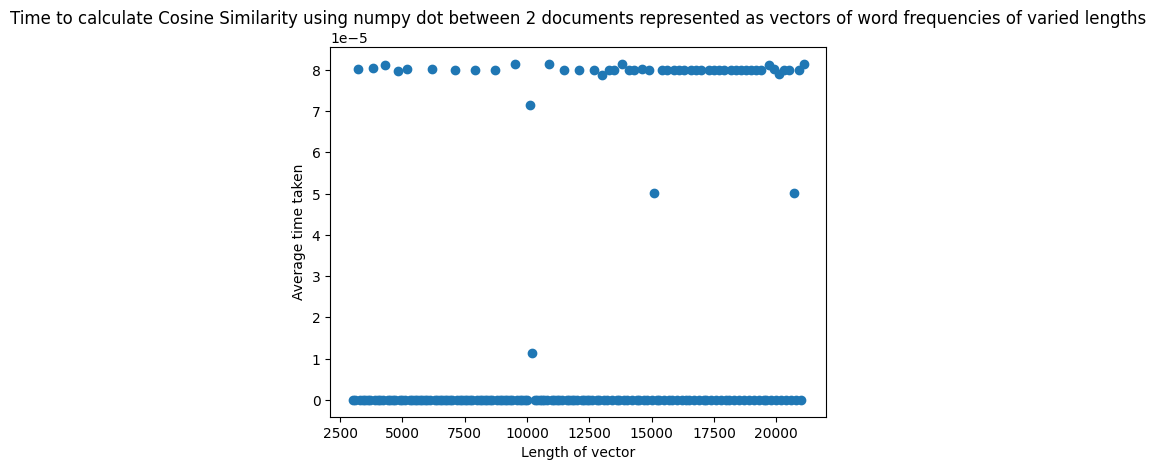

In [41]:
plt.scatter(x_cos_numpy, y_cos_numpy)
#plt.ylim(0,0.005)
plt.xlabel("Length of vector")
plt.ylabel("Average time taken")
plt.title("Time to calculate Cosine Similarity using numpy dot between 2 documents represented as vectors of word frequencies of varied lengths")
plt.show()


C:\Users\georg\AppData\Local\Temp\ipykernel_18380\1353158992.py:2: RuntimeWarning: divide by zero encountered in log10
  log_ycos_numpy = [np.log10(y) for y in y_cos_numpy]


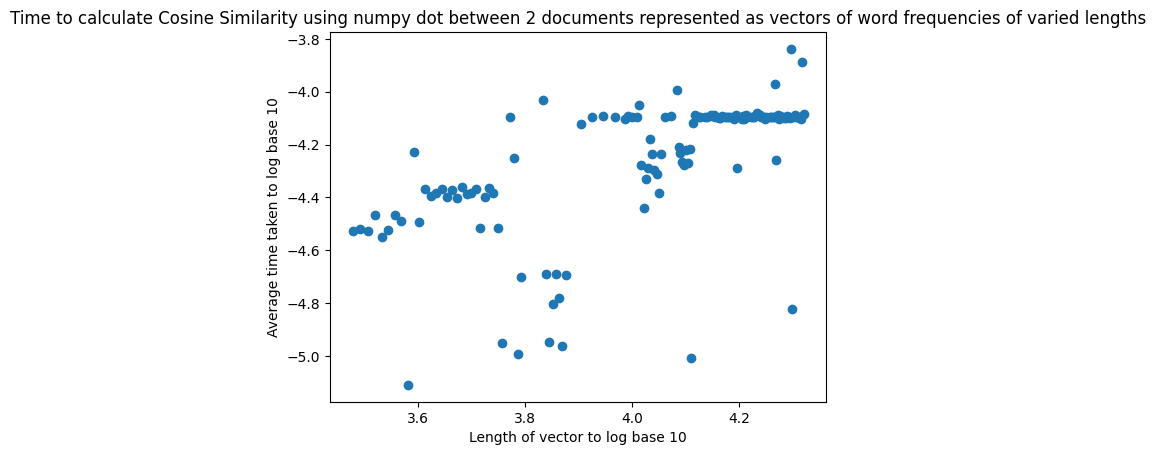

In [234]:
log_xcos_numpy = [np.log10(x) for x in x_cos_numpy]
log_ycos_numpy = [np.log10(y) for y in y_cos_numpy]
#print(log_ycos_numpy)
%matplotlib inline
plt.scatter(log_xcos_numpy,log_ycos_numpy)
#plt.ylim(0,0.005)
plt.xlabel("Length of vector to log base 10")
plt.ylabel("Average time taken to log base 10")
plt.title("Time to calculate Cosine Similarity using numpy dot between 2 documents represented as vectors of word frequencies of varied lengths")
plt.show()

Numpy calculates so fast that it causes multiple divide by zero errors when converting to logarithmic scales so much longer starting lengths are required:

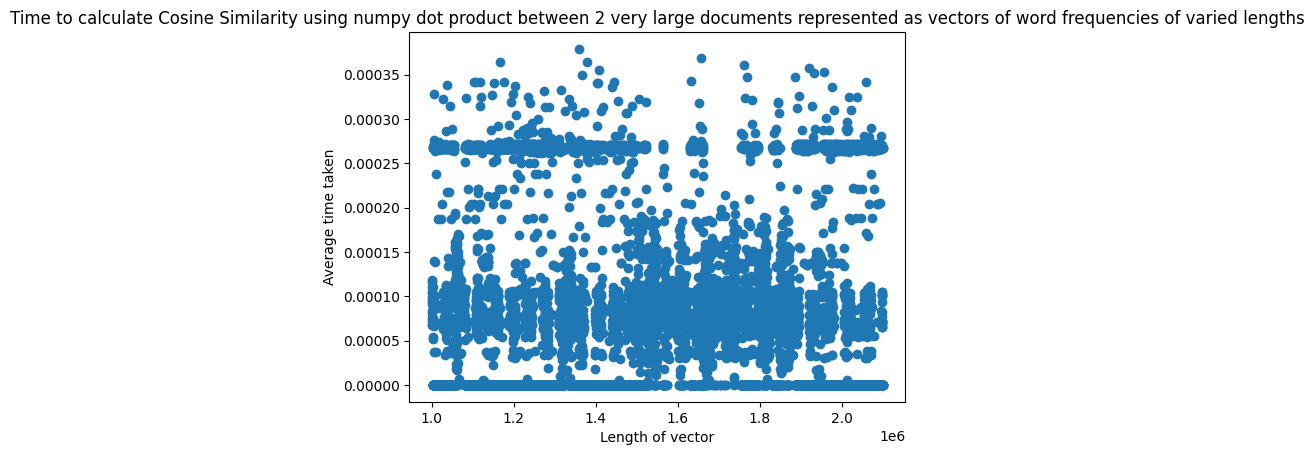

In [236]:
long_doc_1 = doc_1*100
long_doc_2 = doc_2*100

(x_cos_numpy_L, y_cos_numpy_L) = make_data(1000000, 2100000, 100, numpy_cosine, long_doc_1, long_doc_2, repeats=30)

plt.scatter(x_cos_numpy_L,y_cos_numpy_L)
#plt.ylim(0,0.005)
plt.xlabel("Length of vector")
plt.ylabel("Average time taken")
plt.title("Time to calculate Cosine Similarity using numpy dot product between 2 very large documents represented as vectors of word frequencies of varied lengths")
plt.show()


From these results it would seem numpy.dot is independent of n and solves in relatively strict bands of time, most often taking 0.00000 seconds. Perhaps this is because numpy.dot prestores the data for each vector contiguously and precalculates their multiplication and/or summation. No time is spent finding pointers and so the only time it deviates from 0 is when the contiguous data set is so long that it must be broken into smaller chunks that then require some overhead to locate, this makes it much faster than the naive method. Another possibility is that it makes use of precalculated values from earlier actions- it remembers, hence 0. INVESTIGATE MORE

""2) Present an analysis of the theoretical running time of Jaccard’s similarity measure applied to
a pair of documents with data in the format of the provided data matrix. 
Test your analysis empirically by timing and plotting various calculations of Jaccard similarity on your computer. 
Estimate the key constant in the formula for the run-time, for your implementation and computer.""

$Jacc(A,B) = \frac{A \cap B} {A + B - A \cap B}$ extended to bags $Jacc(A,B) = \frac  {\sum_i (min(S_{i1} , S_{i2})} { \sum_i(S_{i1} + S_{i2} - min(S_{i1} , S_{i2}))}$

In Jaccard similarity applied to bags, the time complexity is dominated by the pairwise comparison that arises from the $min$ operation, each comparison is $O(1)$ but there are as many comparisons as there are items in each list, computing all of them is thus an $O(n)$ operation.

In [24]:
#words = data1.index
col1 = data1.iloc[:, 0]
col2 = data1.iloc[:,1]
#print(col1)
#print(col1[:10])


# Jaccard Similarity function
def jaccard(doca, docb):
    intersection =0
    union =0
    
    for i, j in zip(doca, docb):
        intersection += min(i, j)  # Add the minimum count to intersection
        union += max(i, j)         # Add the maximum count to union
    
    return intersection / union if union != 0 else 0  # To avoid division by zero


print(jaccard(doc_1, doc_2))


0.40404040404040403


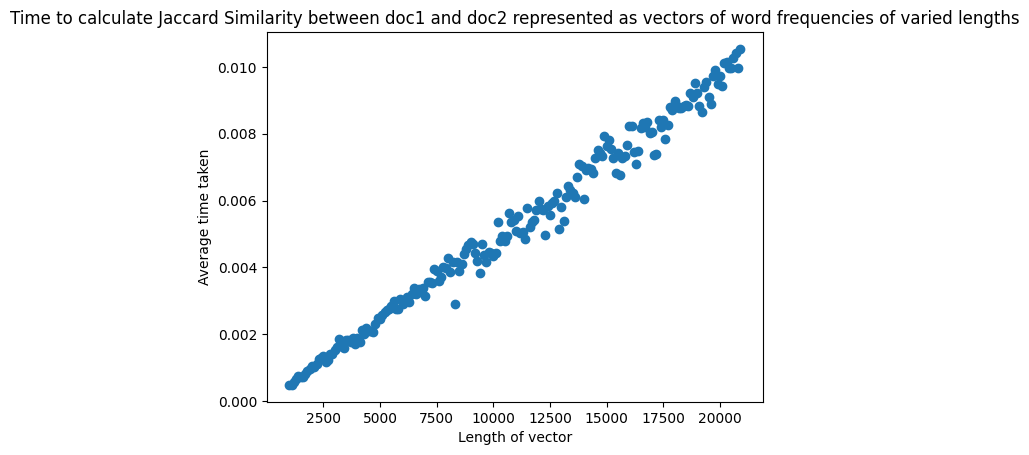

In [177]:
# x_jacc = []
# for n in range(1000,21000, 100): 
#     x_jacc.append(n)
# y_jacc = []
# for n in range(1000, 21000, 100):
#     y_jacc.append(timeit(jaccard, doc_1[:n], doc_2[:n], repeats =100))
(x_jacc, y_jacc) = make_data(1000, 21000, 100, jaccard, doc_1, doc_2, repeats= 100)
plt.scatter(x_jacc,y_jacc)
#plt.ylim(0,0.005)
plt.xlabel("Length of vector")
plt.ylabel("Average time taken")
plt.title("Time to calculate Jaccard Similarity between doc1 and doc2 represented as vectors of word frequencies of varied lengths")
plt.show()

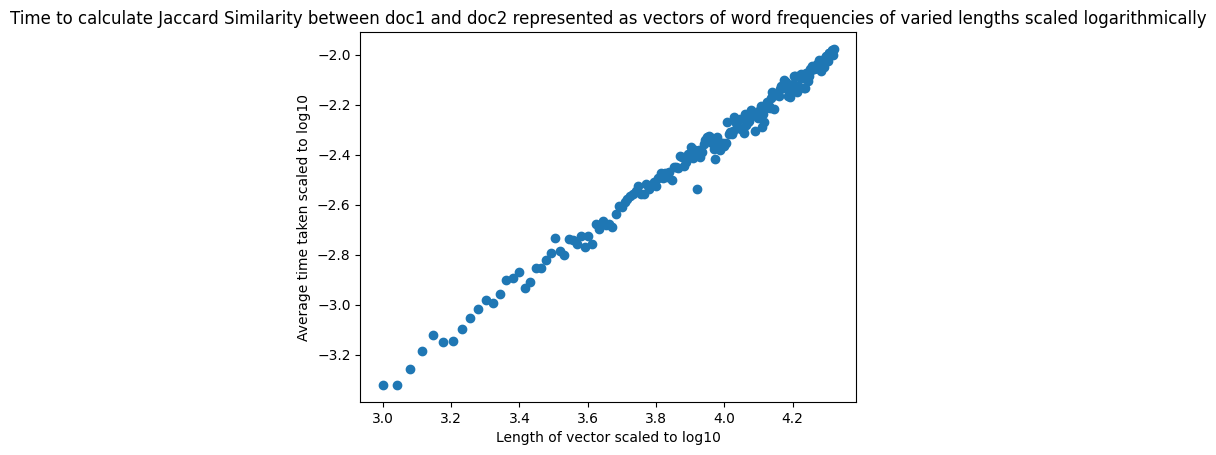

In [179]:
#np.seterr(divide = 'ignore') 
np.seterr(divide = 'warn') 
logxjacc = [np.log10(x) for x in x_jacc]
logyjacc = [np.log10(y) for y in y_jacc]

plt.scatter(logxjacc,logyjacc)
#plt.ylim(0,0.005)
plt.xlabel("Length of vector scaled to log10")
plt.ylabel("Average time taken scaled to log10")
plt.title("Time to calculate Jaccard Similarity between doc1 and doc2 represented as vectors of word frequencies of varied lengths scaled logarithmically")
plt.show()

In [159]:
# print(len(logxjacc))
# print(len(logyjacc))
# print(logxjacc)
# print(logyjacc)

jaccres = stats.linregress(logxjacc, logyjacc)

print("Slope is {} and intercept is {}".format(jaccres.slope,jaccres.intercept))

Slope is 1.0309365596925093 and intercept is -6.649735808586179


"Various calculations of Jaccard"- I hope this is satisfied as I've calculated jaccard for different lengths of the item frequency list for doc1 and doc2.

As expected the slope is around 1. The key constant for this set calculation for my computer was $2.24008342\times10^{-7}$ in this test- incredibily small and represents there being very little overhead to run this experiment.

3) What is the theoretical worst-case running time for computing all-pairs similarities on a data matrix such as the one provided? Does it make a difference which similarity measure is being computed? Estimate the key constant in the all-pairs similarity run-time formula for both Jaccard and cosine similarity.

The theoretical worst-case for computing all-pairs similarities is $O(n^2*d)$ where $d$ is a constant representing dimensionality of the paired items. This occurs when all documents are fully populated and completely dissimilar, so every single word count in every single document is compared with each other document. 

We can simplify this to $O(n^2)$ for sufficiently large data sets. Given that the jaccard/cosine similarity of A with B is the same as B with A we should compute all possible combinations as opposed to permutations and given that the cosine/jaccard similarity with A and A is always 1 it would also be wasteful to compute any similarity measures between identical pairs. Given these restrictions, adding a single document $n$ to our pool of docuents increases the amount of calculations required by $\frac {n(n-1} {2}$ in time complexity terms we can reduce this down to $n^2$ by expanding out the numerator and ignoring all terms of a lower degree. This is faster but of the same degree in time-complexity as working out each permutation of pairs- which scales by $n^2$ with each additional document. So going forward I will be working with unique combinations and not permutations for the sake of efficiency. I would expect either to yield a slope of near 2 on a logarithmic scale and, due to the increased overhead associated with more possible pairings, I would expect to see a higher value for the key constant when computing all possible permutations than with combinations. 

As both Jaccard and Cosine are of $O(n)$ time-complexity, whether we do one or the other does not matter in terms of our worst-case time complexity for computing all-pairs of similarities.

In [185]:
# def make_pairs(list):
#     return [(list_of_docs[i], list_of_docs[j]) for i in range(len(list_of_docs)) for j in range(i + 1, len(list_of_docs))]

# list_of_pairs = make_pairs(list_of_docs)
# #print(list_of_pairs)
# print(len(list_of_pairs)) # =105 pairs with 15docs

def compute_all_pairs_jaccard(documents):
    n = len(documents)
    results = []
    for i in range(n):
        for j in range(i + 1, n):
            results.append(jaccard(documents[i], documents[j]))
    return results  # A list of Jaccard similarity values
    
#print(compute_all_pairs_jaccard(list_of_docs[:15]))
#print(len(compute_all_pairs_jaccard(list_of_docs[:15]))) #is 105 as we expect

xallpairs =[]
for x in range(2, 16): #ignore calc with 0 documents and 1 document
    if len(xallpairs) >= 14:
        xallpairs.clear() #to avoid appending every time this cell is called
        xallpairs.append(x)
    else:
        xallpairs.append(x)
    
yallpairs = []
for y in range(2, 16):
    if len(yallpairs) >=14:
        yallpairs.clear()
        yallpairs.append(timeit(compute_all_pairs_jaccard, list_of_docs[:y], repeats = 20))
    else:
        yallpairs.append(timeit(compute_all_pairs_jaccard, list_of_docs[:y], repeats = 20))

#Could be worth testing with fewer pairs to see if the easier load is handled faster and closer to the theoretical limit.

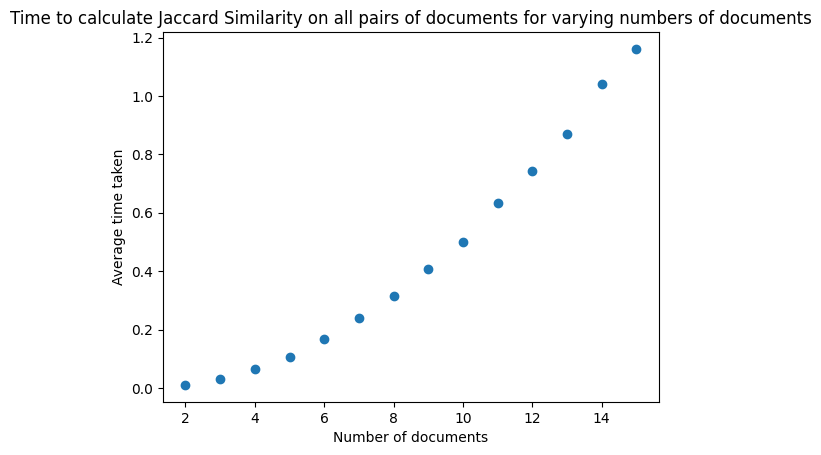

In [48]:
plt.scatter(xallpairs, yallpairs)
#plt.ylim(0,0.005)
plt.xlabel("Number of documents")
plt.ylabel("Average time taken")
plt.title("Time to calculate Jaccard Similarity on all pairs of documents for varying numbers of documents")
plt.show()

This curviture indicates quadratic growth which would match up with our theory- it appears as if it would line up with the positive section of the curve $y = mx^2$ where $m$ is a constant. Scalling the graph to $log_10$, we should expect a slope of near $2$ to confirm this:

In [58]:
logxallpairs = [np.log10(x) for x in xallpairs]
logyallpairs = [np.log10(y) for y in yallpairs]

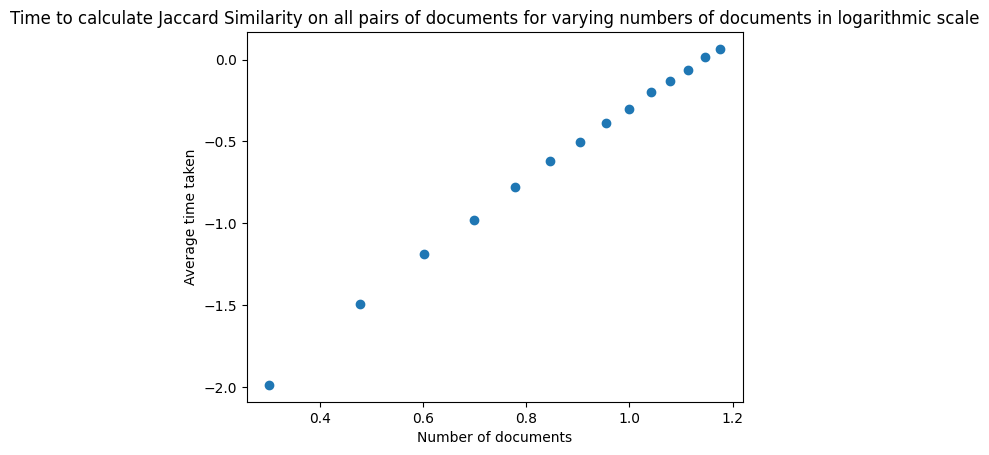

In [72]:
plt.scatter(logxallpairs,logyallpairs)
#plt.ylim(0,0.005)
plt.xlabel("Number of documents")
plt.ylabel("Average time taken")
plt.title("Time to calculate Jaccard Similarity on all pairs of documents for varying numbers of documents in logarithmic scale")
plt.show()

In [56]:
apjaccres = stats.linregress(logxallpairs, logyallpairs)
print("Slope is {} and intercept is {}".format(apjaccres.slope,apjaccres.intercept))

Slope is 2.3084212828893316 and intercept is -2.6087808455526114


After various retests the slope seems to vary between 2.20 and 2.33 and our key intercept seems to be between 0.0023 and 0.0025- This is in-line with our prediction as a slope of 2 is our theoretical limit. I hypothesize that the reading for slope should be relatively similar for computing cosine similarity for all pairs:

In [204]:
def compute_all_pairs_cosine(documents):
    n = len(documents)
    results = []
    for i in range(n):
        for j in range(i + 1, n):
            results.append(cosine_n(documents[i], documents[j]))
    return results  # A list of cosine similarity values

x_ap_cos =[]
for x in range(2, 16): #ignore calc with 0 documents and 1 document
    if len(x_ap_cos) >= 14:
        x_ap_cos.clear()
        x_ap_cos.append(x)
    else:
        x_ap_cos.append(x)
    
    
y_ap_cos = []
         
for y in range(2, 16):
    if len(y_ap_cos) >= 14:
        y_ap_cos.clear()
        y_ap_cos.append(timeit(compute_all_pairs_cosine, list_of_docs[:y], repeats = 20))
    else:
        y_ap_cos.append(timeit(compute_all_pairs_cosine, list_of_docs[:y], repeats = 20))

In [206]:
logxap_cos = [np.log10(x) for x in x_ap_cos]
logyap_cos = [np.log10(y) for y in y_ap_cos]

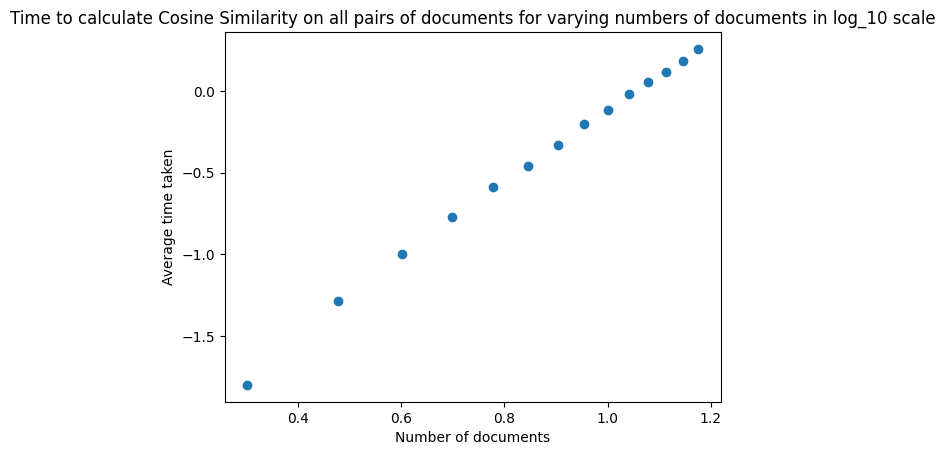

In [208]:
plt.scatter(logxap_cos,logyap_cos)
#plt.ylim(0,0.005)
plt.xlabel("Number of documents")
plt.ylabel("Average time taken")
plt.title("Time to calculate Cosine Similarity on all pairs of documents for varying numbers of documents in log_10 scale")
plt.show()

In [194]:
# plt.scatter(x_ap_cos,logyap_cos)
# #plt.ylim(0,0.005)
# plt.xlabel("Number of documents")
# plt.ylabel("Average time taken")
# plt.title("Time to calculate Cosine Similarity on all pairs of documents for varying numbers of documents in logarithmic scale")
# plt.show()

# print(len(x_ap_cos))
# print(x_ap_cos)
# print(len(logyap_cos))

In [210]:
apcosres = stats.linregress(logxap_cos, logyap_cos)
print("Slope is {} and intercept is {}".format(apcosres.slope,apcosres.intercept))

Slope is 2.283943769901351 and intercept is -2.400677146271206


As expected thee slope and y intercept remain very similar for computing the naive cosine similarity or jaccard on all-pairs.

In [238]:
def compute_all_pairs_cosine_numpy(documents):
    n = len(documents)
    results = []
    for i in range(n):
        for j in range(i + 1, n):
            results.append(numpy_cosine(documents[i], documents[j]))
    return results  # A list of cosine similarity values

x_ap_cos_numpy =[]
for x in range(2, 16): #ignore calc with 0 documents and 1 document
    if len(x_ap_cos) >= 14:
        x_ap_cos_numpy.clear()
        x_ap_cos_numpy.append(x)
    else:
        x_ap_cos_numpy.append(x)
    
y_ap_cos_numpy = []
for y in range(2, 16):
    if len(y_ap_cos) >= 14:
        y_ap_cos_numpy.clear()
        y_ap_cos_numpy.append(timeit(compute_all_pairs_cosine_numpy, list_of_docs[:y], repeats = 20))
    else: 
        y_ap_cos_numpy.append(timeit(compute_all_pairs_cosine_numpy, list_of_docs[:y], repeats = 20))


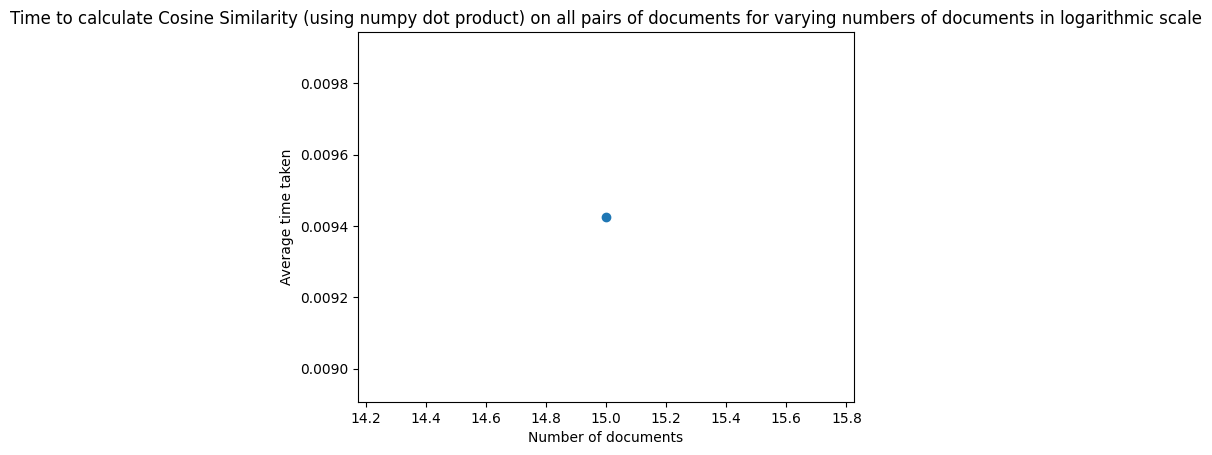

In [240]:
plt.scatter(x_ap_cos_numpy,y_ap_cos_numpy)
#plt.ylim(0,0.005)
plt.xlabel("Number of documents")
plt.ylabel("Average time taken")
plt.title("Time to calculate Cosine Similarity (using numpy dot product) on all pairs of documents for varying numbers of documents in logarithmic scale")
plt.show()

Write a function that implements all-pairs similarities for one of the similarity measures, using some form of parallel computing. Analyse theoretically and empirically how much speed up it is possible to achieve on your computer.

In [ ]:
import multiprocessing
from itertools import combinations
from timeit import default_timer as timer

def compute_pairwise_chunk(chunk):
    """Compute cosine similarities for a chunk of document pairs."""
    return [cosine_n(pair[0], pair[1]) for pair in chunk]

def compute_all_pairs_cosine_multiprocessing(documents, num_processes):
    """Compute cosine similarities using multiprocessing."""
    # Create all pairs of documents
    pairs = list(combinations(documents, 2))
    chunk_size = len(pairs) // num_processes
    chunks = [pairs[i * chunk_size: (i + 1) * chunk_size] for i in range(num_processes)]

    # Handle the remainder
    if len(pairs) % num_processes:
        chunks[-1].extend(pairs[num_processes * chunk_size:])

    with multiprocessing.Pool(processes=num_processes) as pool:
        results = pool.map(compute_pairwise_chunk, chunks)

    # Flatten the list of results
    return [sim for sublist in results for sim in sublist]

# Measure time for different number of processes
x_ap_cos_mult = list(range(2, 16))
y_ap_cos_mult = []

list_of_docs
repeats = 20

for num_processes in x_ap_cos_mult:
    start = timer()
    for _ in range(repeats):
        compute_all_pairs_cosine_multiprocessing(list_of_docs[:num_processes], num_processes)
    end = timer()
    avg_time = (end - start) / repeats
    y_ap_cos_mult.append(avg_time)
